In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, shapiro, kruskal, mannwhitneyu, tukey_hsd, ttest_ind
from statsmodels.stats.oneway import anova_oneway

([Swap(1), Reversion(1), Insertion(1), Slide(1)])

([Swap(2), Reversion(2), Insertion(2), Slide(2)])

([Swap(3), Reversion(3), Insertion(3), Slide(3)])

([Swap(4), Reversion(4), Insertion(4), Slide(4)])

In [3]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [4]:
# Deterministic
filename = 'FX_values_2_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]
c0 = data[2, :]
d0 = data[3, :]

# Stochastic
filename = 'FX_values_2_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]
c1 = data[2, :]
d1 = data[3, :]

## Deterministic

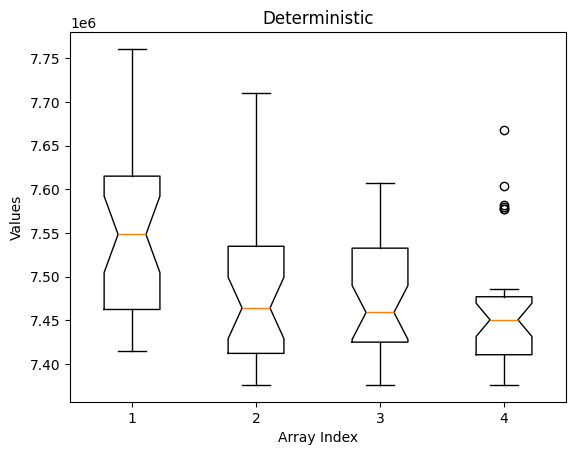

In [5]:
filename = 'FX_values_2_0.npz'
plot_boxplots(filename, "Deterministic")

In [6]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))
print(shapiro(d0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.9156943000722519, pvalue=0.020769258328643323)
ShapiroResult(statistic=0.8479219431919794, pvalue=0.0005610998991453112)
ShapiroResult(statistic=0.9088615971057578, pvalue=0.013930051727367953)
ShapiroResult(statistic=0.8718882246422641, pvalue=0.0018459299925783254)


In [7]:
# H0: the medians of the groups are equal

print(kruskal(a0, b0, c0, d0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=14.375348068513828, pvalue=0.0024363072512684687)


In [16]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='two-sided')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='two-sided')}")
print(f"a vs d: {mannwhitneyu(a0, d0, alternative='two-sided')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='two-sided')}")
print(f"b vs d: {mannwhitneyu(b0, d0, alternative='two-sided')}")
print(f"c vs d: {mannwhitneyu(c0, d0, alternative='two-sided')}")

# Comparisons with 'greater' alternative hypothesis
print(f"a vs b: {mannwhitneyu(a0, b0, alternative='greater')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='greater')}")
print(f"a vs d: {mannwhitneyu(a0, d0, alternative='greater')}")

a vs b: MannwhitneyuResult(statistic=612.5, pvalue=0.01655208735762016)
a vs c: MannwhitneyuResult(statistic=643.5, pvalue=0.00430393917063291)
a vs d: MannwhitneyuResult(statistic=687.0, pvalue=0.0004675242479855093)
b vs c: MannwhitneyuResult(statistic=468.5, pvalue=0.7900016951381464)
b vs d: MannwhitneyuResult(statistic=527.0, pvalue=0.25743576615029395)
c vs d: MannwhitneyuResult(statistic=514.5, pvalue=0.3435080339058135)
a vs b: MannwhitneyuResult(statistic=612.5, pvalue=0.00827604367881008)
a vs c: MannwhitneyuResult(statistic=643.5, pvalue=0.002151969585316455)
a vs d: MannwhitneyuResult(statistic=687.0, pvalue=0.00023376212399275464)


a != b

a != c

a != d

There is no significant difference between the other pairs.

a has higher values than b, c and d.

## Stochastic

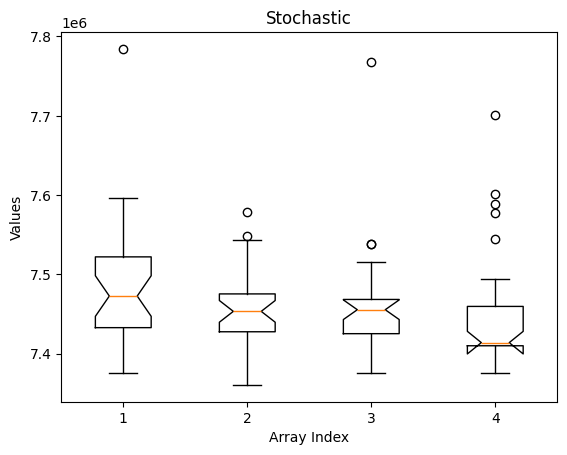

In [9]:
filename = 'FX_values_2_1.npz'
plot_boxplots(filename, "Stochastic")

In [10]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a1))
print(shapiro(b1))
print(shapiro(c1))
print(shapiro(d1))

# Based on the results, B is normally distributed. A, C and D are not.

ShapiroResult(statistic=0.8645817897674096, pvalue=0.0012720691963069145)
ShapiroResult(statistic=0.9404422852393467, pvalue=0.0934883003100852)
ShapiroResult(statistic=0.7374478080818857, pvalue=5.745235528532958e-06)
ShapiroResult(statistic=0.7688355740371952, pvalue=1.863561876091953e-05)


In [11]:
# H0: the medians of the groups are equal

print(kruskal(a1, b1, c1, d1))

# since H0 is rejected, the medians are not equal.
# but its very close to not beign rejected.

KruskalResult(statistic=8.273209619460507, pvalue=0.04069018304680042)


In [17]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a1, b1, alternative='two-sided')}")
print(f"a vs c: {mannwhitneyu(a1, c1, alternative='two-sided')}")
print(f"a vs d: {mannwhitneyu(a1, d1, alternative='two-sided')}")
print(f"b vs c: {mannwhitneyu(b1, c1, alternative='two-sided')}")
print(f"b vs d: {mannwhitneyu(b1, d1, alternative='two-sided')}")
print(f"c vs d: {mannwhitneyu(c1, d1, alternative='two-sided')}")

print(f"a vs d: {mannwhitneyu(a0, d0, alternative='greater')}")

a vs b: MannwhitneyuResult(statistic=550.5, pvalue=0.1390475666454184)
a vs c: MannwhitneyuResult(statistic=577.5, pvalue=0.06035433409861767)
a vs d: MannwhitneyuResult(statistic=622.0, pvalue=0.011197295224460368)
b vs c: MannwhitneyuResult(statistic=459.5, pvalue=0.8940069060118382)
b vs d: MannwhitneyuResult(statistic=551.5, pvalue=0.13481834832655545)
c vs d: MannwhitneyuResult(statistic=548.5, pvalue=0.1468778230410771)
a vs d: MannwhitneyuResult(statistic=687.0, pvalue=0.00023376212399275464)


a != d

There is no significant difference between the other pairs.

a has higher values than d.

# Deterministic x Stochastic

In [19]:
# H0: the medians of the groups are equal

print(f"a0 vs a1: {mannwhitneyu(a0, a1, alternative='two-sided')}")
print(f"b0 vs b1: {mannwhitneyu(b0, b1, alternative='two-sided')}")
print(f"c0 vs c1: {mannwhitneyu(c0, c1, alternative='two-sided')}")
print(f"d0 vs d1: {mannwhitneyu(d0, d1, alternative='two-sided')}")

print(f"a0 vs a1: {mannwhitneyu(a0, a1, alternative='greater')}")

a0 vs a1: MannwhitneyuResult(statistic=609.5, pvalue=0.01871721608018964)
b0 vs b1: MannwhitneyuResult(statistic=522.5, pvalue=0.286481742352638)
c0 vs c1: MannwhitneyuResult(statistic=507.0, pvalue=0.4031844913240049)
d0 vs d1: MannwhitneyuResult(statistic=508.0, pvalue=0.39473451701891793)
a0 vs a1: MannwhitneyuResult(statistic=609.5, pvalue=0.00935860804009482)


a0 != a1

There is no significant difference between the other pairs.

a0 has higher values than a1.